In [1]:
# SIRYA: metti entrambi a True se sei su colab
COLAB = False
SIRYA = False

if COLAB:

    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    !rm -rf LCTSCProject2024
    !git clone https://github.com/AI-For-Experimental-And-Applied-Physics/LCTSCProject2024.git
    !pip install itkwidgets
    !pip install -r LCTSCProject2024/requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pydicom
import os

from ipywidgets import interact, IntSlider, FloatSlider
import itkwidgets as viewer

In [3]:
if SIRYA:
    data_base_dir = '/content/drive/MyDrive/Colab Notebooks/Biomedical Imaging/DATA'
    data_csv = '/content/drive/MyDrive/Colab Notebooks/Biomedical Imaging/DATA/lctsc_metadata.csv'
else:
    data_base_dir = './'
    data_csv = './lctsc_metadata.csv'

## Exploring the Dataset Structure and Metadata

Let's start by exploring the directory structure and reading the metadata from the DICOM files.

In [4]:
# Load the metadata.csv file
metadata_df = pd.read_csv(data_csv)

# Display the first few rows and column information
print(metadata_df.head())
print(metadata_df.info())

                                          Series UID Collection  \
0  1.3.6.1.4.1.14519.5.2.1.7014.4598.280355341349...      LCTSC   
1  1.3.6.1.4.1.14519.5.2.1.7014.4598.110977663386...      LCTSC   
2  1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850...      LCTSC   
3  1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487...      LCTSC   
4  1.3.6.1.4.1.14519.5.2.1.7014.4598.941697026234...      LCTSC   

   3rd Party Analysis                           Data Description URI  \
0                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
1                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
2                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
3                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   
4                 NaN  https://doi.org/10.7937/K9/TCIA.2017.3r3fvz08   

          Subject ID                                          Study UID  \
0  LCTSC-Test-S1-101  1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630...   
1  LCTSC-Test-

In [5]:
# fill the patient dict variable
patient_dict = {}

# Method 2: Using itertuples() (More efficient than iterrows())
for row in metadata_df.itertuples():
  patient_id = getattr(row, '_5') # unique Name
  file_type = getattr(row, 'Modality') # check if RTSTRUCT or CT
  file_location = getattr(row, '_16') # Path to the images
  if patient_id in patient_dict.keys() :
    patient_dict[patient_id][file_type] = file_location
  else:
    patient_dict[patient_id] = {}
    patient_dict[patient_id][file_type] = file_location

print(patient_dict)

{'LCTSC-Test-S1-101': {'RTSTRUCT': './LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.280355341349691222365783556597', 'CT': './LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850011666503487579262'}, 'LCTSC-Test-S1-102': {'RTSTRUCT': './LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.110977663386843546355807661874', 'CT': './LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.639871532605224417554459681163'}, 'LCTSC-Test-S1-103': {'CT': './LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475068003264/1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487402949445746417374', 'RTSTRUCT': './LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475

In [6]:
def load_patient_dicom_files(patient_dir):
    """Loads all DICOM files from a patient directory."""
    dicom_files = []
    for filename in os.listdir(patient_dir):
        if filename.endswith('.dcm'):
            file_path = os.path.join(patient_dir, filename)
            try:
                dicom_files.append(pydicom.dcmread(file_path))
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    return dicom_files

def get_patient_metadata(dicom_files):
    """Extracts relevant metadata from a list of DICOM files for a patient."""
    if not dicom_files:
        return None
    metadata = {
        'PatientID': dicom_files[0].PatientID if 'PatientID' in dicom_files[0] else None,
        'PatientSex': dicom_files[0].PatientSex if 'PatientSex' in dicom_files[0] else None,
        'PatientAge': dicom_files[0].PatientAge if 'PatientAge' in dicom_files[0] else None,
        'StudyDate': dicom_files[0].StudyDate if 'StudyDate' in dicom_files[0] else None,
        'SeriesDescription': dicom_files[0].SeriesDescription if 'SeriesDescription' in dicom_files[0] else None,
        'NumberOfSlices': len(dicom_files),
        # Add more relevant metadata as needed
    }
    return metadata

# # Iterate through the patient directories and collect metadata
# all_metadata = []

# for k,v in patient_dict.items():
#   if v['CT']:
#     dicom_files = load_patient_dicom_files(os.path.join(data_base_dir,v['CT'].replace('./','')))
# #     if dicom_files:
#         print(f"Patient ID: {k}, Number of DICOM files: {len(dicom_files)}")
#         metadata = get_patient_metadata(dicom_files)
#         all_metadata.append(metadata)

# # Create a Pandas DataFrame from the collected metadata
# metadata_df = pd.DataFrame(all_metadata)

# # Display the first few rows of the metadata DataFrame
# print("First few rows of the metadata DataFrame:")
# print(metadata_df.head())

# # Basic statistics of the metadata
# print("\nBasic statistics of the metadata:")
# print(metadata_df.describe(include='all'))



## Visualizing Individual CT Slices

Let's visualize individual slices from a CT scan.

In [7]:
# def display_slice(dicom_file):
#     """Displays a single CT scan slice."""
#     plt.figure(figsize=(8, 8))
#     plt.imshow(dicom_file.pixel_array, cmap=plt.cm.gray)
#     plt.title(f"Slice: {dicom_file.ImagePositionPatient[2]:.2f}")
#     plt.xlabel("Pixels")
#     plt.ylabel("Pixels")
#     plt.axis('off')
#     plt.show()

# # Example: Load and display a slice from the first patient
# first_key = next(iter(patient_dict))
# first_value = patient_dict[first_key]

# if first_value['CT']:
#   first_patient_files = load_patient_dicom_files(os.path.join(data_base_dir,first_value['CT'].replace('./','')))
#   if first_patient_files:
#       display_slice(first_patient_files[len(first_patient_files) // 2]) # Display the middle slice


In [8]:
# Interactive slice viewer
def interactive_slice_viewer(dicom_files):
    """Interactive viewer for browsing through CT scan slices."""
    slices = [dcm.pixel_array for dcm in dicom_files]
    def show_slice(slice_num):
        plt.figure(figsize=(8, 8))
        plt.imshow(slices[slice_num], cmap=plt.cm.gray)
        plt.title(f"Slice: {slice_num}")
        plt.xlabel("Pixels")
        plt.ylabel("Pixels")
        plt.axis('off')
        plt.show()

    interact(show_slice, slice_num=IntSlider(min=0, max=len(slices) - 1, step=1, description='Slice Number'))

# Example: Interactive slice viewing for the first patient
first_key = next(iter(patient_dict))
first_value = patient_dict[first_key]

if first_value['CT']:
  first_patient_files = load_patient_dicom_files(os.path.join(data_base_dir,first_value['CT'].replace('./','')))
  if first_patient_files:
      interactive_slice_viewer(first_patient_files)


interactive(children=(IntSlider(value=0, description='Slice Number', max=129), Output()), _dom_classes=('widge…

## Statistical Analysis of the Dataset

Now, let's perform some statistical analysis on the metadata we collected.

In [9]:
# # Distribution of Patient Sex
# if 'PatientSex' in metadata_df.columns:
#     plt.figure(figsize=(6, 4))
#     sns.countplot(data=metadata_df, x='PatientSex')
#     plt.title('Distribution of Patient Sex')
#     plt.xlabel('Sex')
#     plt.ylabel('Number of Patients')
#     plt.show()

In [10]:
# # Distribution of Number of Slices per Patient
# if 'NumberOfSlices' in metadata_df.columns:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(metadata_df['NumberOfSlices'], bins=30, kde=True)
#     plt.title('Distribution of Number of Slices per Patient')
#     plt.xlabel('Number of Slices')
#     plt.ylabel('Number of Patients')
#     plt.show()

# Preprocessing

In [11]:
import sys
from pathlib import Path

# Add the LCTSCProject2024 parent directory to the Python path
sys.path.append("LCTSCProject2024/")

import pandas as pd
from lctsc_preprocessor.dicom_utils import load_ct_series
from pathlib import Path
from lctsc_preprocessor.rtstruct_utils import load_rtstruct

OUTPUT_DIR = Path('./data_processed')

import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage

In [12]:
from scipy.ndimage import zoom

def resize_volume(image: np.ndarray, dim: int):

    H, W, Z = image.shape

    zoom_factors = (
        dim / H,
        dim / W,
        1.0
    )

    resized = zoom(image, zoom=zoom_factors, order=1)
    return resized

In [13]:
def hu_windowing(image: np.ndarray, window_min = -1000, window_max = 400):
    '''
    Apply a Hounsfield Units (HU) windowing to an image.
    '''

    windowed_image = np.clip(image, window_min, window_max)

    return windowed_image

In [14]:
def zoom_on_lungs(mask:np.ndarray, pad = 0.2):

    y, x, z = np.where(mask > 0)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    H, W, Z = mask.shape
    pad_y = int(H * pad)
    pad_x = int(W * pad)
    pad_z = int(Z * pad)

    x_min_pad = max(0, x_min - pad_x)
    x_max_pad = min(W - 1, x_max + pad_x)
    y_min_pad = max(0, y_min - pad_y)
    y_max_pad = min(H - 1, y_max + pad_y)
    z_min_pad = max(0, z_min - pad_z)
    z_max_pad = min(Z - 1, z_max + pad_z)

    return x_min_pad, x_max_pad, y_min_pad, y_max_pad, z_min_pad, z_max

In [16]:
def preprocess_case(case_id: str, ct_path: str, rtstruct_path: str, w_min: int, w_max: int, plot=False):
    ct_dir = Path(ct_path)
    rt_file = Path(rtstruct_path)

    if not ct_dir.exists() or not rt_file.exists():
        print(f"[!] Skipping {case_id}: CT or RTSTRUCT path missing.")
        return

    try:
        raw_image, pixel_dim = load_ct_series(ct_dir) ## ricordati di cambiare!!!

        print(f'Original image shape: {raw_image.shape}')
        # print(f'Original pixel dimensions: {pixel_dim}')

        rtstruct = load_rtstruct(rt_file, ct_dir)
        roi_names = rtstruct.get_roi_names()

        r_lung = rtstruct.get_roi_mask_by_name('Lung_R').astype(np.uint8)
        l_lung = rtstruct.get_roi_mask_by_name('Lung_L').astype(np.uint8)

        mask = np.maximum(r_lung, l_lung).astype(np.uint8)

        x1, x2, y1, y2, z1, z2 = zoom_on_lungs(mask)

        crop_img = raw_image[y1:y2+1, x1:x2+1, z1:z2+1]
        image = hu_windowing(crop_img, w_min, w_max)
        resize_img = resize_volume(image, 128)
        
        # Normalize to [0, 1] using HU windowing parameters
        normalized_img = (resize_img - w_min) / (w_max - w_min)

        mask_dict = {}
        for roi in roi_names:
            try:
                mask_roi = rtstruct.get_roi_mask_by_name(roi).astype(np.uint8)
                crop_mask = mask_roi[y1:y2+1, x1:x2+1, z1:z2+1]
                resize_mask = resize_volume(crop_mask, 128)

                mask_dict[roi] = resize_mask


            except Exception as e:
                print(f"[!] Could not extract ROI '{roi}' for {case_id}: {e}")

        print(f'Cropped image shape: {crop_img.shape}')
        print(f'Resized image shape: {resize_img.shape}')
        print(f'Normalized image range: [{normalized_img.min():.3f}, {normalized_img.max():.3f}]')
        print(f'Cropped mask shape: {crop_mask.shape}')
        print(f'Resized mask shape: {resize_mask.shape}')

        if mask_dict:
            if case_id.find('Train') != -1:
                dir = OUTPUT_DIR / 'Train'
            else:
                dir = OUTPUT_DIR / 'Test'
            dir.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(
                dir / f"{case_id}.npz",
                image=normalized_img,  # Save normalized image
                pixel_dim=pixel_dim,
                **mask_dict
            )
            print(f"[✓] Saved {case_id} with {len(mask_dict)} ROIs.")

        else:
            print(f"[!] No valid ROIs found for {case_id}.")
        if plot:
            plot_roi_overlays(normalized_img, list(mask_dict.values()), list(mask_dict.keys()), [1,1,1])
    except Exception as e:
        print(f"[!] Error processing {case_id}: {e}")


def plot_roi_overlays(image, masks, roi_names, pixel_dim=[1,1,1]):
    print(pixel_dim)
    # Define colors for ROIs
    colors = plt.colormaps.get_cmap('tab10')
    alpha = 0.25  # Transparency for the overlays

    # Create a combined mask for each ROI
    combined_masks = np.zeros_like(image, dtype=np.float32)
    for i, mask in enumerate(masks):
        combined_masks += mask * (i + 1)

    # Create a custom colormap for the ROIs
    cmap = ListedColormap([colors(i) for i in range(len(roi_names)+1)])

    # Plot on all three planes
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    planes = ['Coronal', 'Axial', 'Sagittal']

    # Coronal plane
    mid_coronal = image.shape[0] // 2
    axes[0].imshow(image[mid_coronal], cmap='gray', aspect=pixel_dim[1] / pixel_dim[2])
    axes[0].imshow(combined_masks[mid_coronal], cmap=cmap, alpha=alpha, aspect=pixel_dim[1] / pixel_dim[2],vmin=0,vmax=len(roi_names)+1)
    axes[0].set_title(f"{planes[0]} Plane")
    axes[0].axis('off')

    # Axial plane
    mid_axial = image.shape[2] // 2
    axes[1].imshow(image[:, :, mid_axial], cmap='gray', aspect=pixel_dim[0] / pixel_dim[1])
    axes[1].imshow(combined_masks[:, :, mid_axial], cmap=cmap, alpha=alpha, aspect=pixel_dim[0] / pixel_dim[1],vmin=0,vmax=len(roi_names)+1)
    axes[1].set_title(f"{planes[1]} Plane")
    axes[1].axis('off')

    # Sagittal plane
    mid_sagittal = image.shape[1] // 2
    axes[2].imshow(image[:, mid_sagittal, :], cmap='gray', aspect=pixel_dim[0] / pixel_dim[2])
    axes[2].imshow(combined_masks[:, mid_sagittal, :], cmap=cmap, alpha=alpha, aspect=pixel_dim[0] / pixel_dim[2],vmin=0,vmax=len(roi_names)+1)
    axes[2].set_title(f"{planes[2]} Plane")
    axes[2].axis('off')

    # Add a legend for ROI names
    handles = [plt.Line2D([0], [0], color=colors(i+1), lw=4) for i in range(len(roi_names))]
    fig.legend(handles, roi_names, loc='upper center', ncol=len(roi_names), bbox_to_anchor=(0.5, 0.95))

    plt.tight_layout()
    plt.show()

In [ ]:
for k,v in patient_dict.items():
    print(Path(data_base_dir).joinpath(v["CT"]))
    preprocess_case(
        case_id = k,
        ct_path = Path(data_base_dir).joinpath(v["CT"]),
        rtstruct_path = Path(data_base_dir).joinpath(v["RTSTRUCT"]).joinpath('1-1.dcm'),
        w_min = -1000,
        w_max = 400,
        plot=False
    )

LCTSC/LCTSC-Test-S1-101/1.3.6.1.4.1.14519.5.2.1.7014.4598.492964872630309412859177308186/1.3.6.1.4.1.14519.5.2.1.7014.4598.106943890850011666503487579262
Original image shape: (512, 512, 130)
Cropped image shape: (405, 511, 102)
Resized image shape: (128, 128, 102)
Normalized image range: [-0.000, 1.000]
Cropped mask shape: (405, 511, 102)
Resized mask shape: (128, 128, 102)
[✓] Saved LCTSC-Test-S1-101 with 5 ROIs.
LCTSC/LCTSC-Test-S1-102/1.3.6.1.4.1.14519.5.2.1.7014.4598.238478060677653494401819620444/1.3.6.1.4.1.14519.5.2.1.7014.4598.639871532605224417554459681163
Original image shape: (512, 512, 148)
Cropped image shape: (408, 474, 99)
Resized image shape: (128, 128, 99)
Normalized image range: [-0.000, 1.000]
Cropped mask shape: (408, 474, 99)
Resized mask shape: (128, 128, 99)
[✓] Saved LCTSC-Test-S1-102 with 5 ROIs.
LCTSC/LCTSC-Test-S1-103/1.3.6.1.4.1.14519.5.2.1.7014.4598.816327386653410772475068003264/1.3.6.1.4.1.14519.5.2.1.7014.4598.578895540487402949445746417374
Original ima

In [ ]:
# Visualize a preprocessed case
data = np.load(OUTPUT_DIR / "Train" / "LCTSC-Train-S1-001.npz")
image = data['image']
mask_rlung = data['Lung_R']
mask_llung = data['Lung_L']


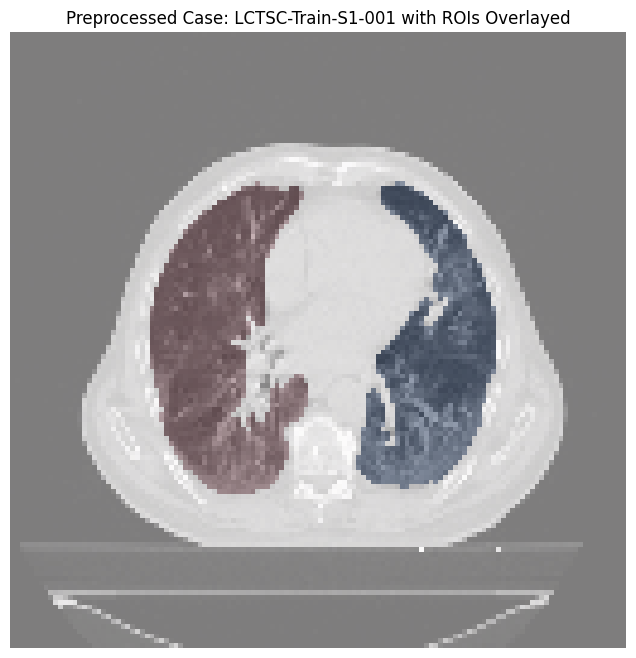

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(image[:, :, image.shape[2] // 2], cmap='gray')
plt.imshow(mask_rlung[:, :, image.shape[2] // 2], cmap='Reds', alpha=0.3)
plt.imshow(mask_llung[:, :, image.shape[2] // 2], cmap='Blues', alpha=0.3)
plt.title(f"Preprocessed Case: LCTSC-Train-S1-001 with ROIs Overlayed")
plt.axis('off')
plt.show()

In [17]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import time # To time epochs
from tqdm import tqdm # For progress bars

In [18]:
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"GPU memory cleared. Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

GPU memory cleared. Available: 8.00 GB


In [41]:
# Data Augmentation Pipeline with Albumentations
import monai.transforms as mt

train_transform_3d = mt.Compose([
    mt.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),  # Flip orizzontale
    mt.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),  # Flip verticale
    mt.RandRotate90d(keys=["image", "mask"], prob=0.5, spatial_axes=(0, 1)),
    mt.RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.1),
    mt.RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.9, 1.1)),
    mt.RandGaussianSmoothd(keys=["image"], prob=0.2, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
])

val_transform_3d = mt.Compose([])  # Nessuna augmentation per validation

# ============================================================================
# DATASET 3D - Per training volumetrico con patch
# ============================================================================

class LCTSC_Dataset_3D(Dataset):
    def __init__(self, data_dir, patch_size=(64, 64, 32), transform=None):
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.transform = transform
        self.volumes = []
        
        print("Loading 3D volumes into memory...")
        for file_name in sorted(os.listdir(data_dir)):
            if file_name.endswith('.npz'):
                file_path = os.path.join(data_dir, file_name)
                try:
                    npz_file = np.load(file_path)
                    image = npz_file['image']
                    mask_r = npz_file['Lung_R']
                    mask_l = npz_file['Lung_L']
                    mask = np.maximum(mask_r, mask_l).astype(np.float32)
                    
                    self.volumes.append({
                        'image': image.astype(np.float32),
                        'mask': mask,
                        'name': file_name
                    })
                    npz_file.close()
                    print(f"  ✓ Loaded {file_name}: {image.shape}")
                except Exception as e:
                    print(f"  ✗ Error loading {file_name}: {e}")
        
        print(f"Total volumes loaded: {len(self.volumes)}\n")

    def __len__(self):
        return len(self.volumes) * 8

    def __getitem__(self, idx):
        vol_idx = idx % len(self.volumes)
        data = self.volumes[vol_idx]
        
        image = data['image'].copy()
        mask = data['mask'].copy()
        
        # Random patch extraction
        H, W, D = image.shape
        pH, pW, pD = self.patch_size
        
        max_h = max(0, H - pH)
        max_w = max(0, W - pW)
        max_d = max(0, D - pD)
        
        h = np.random.randint(0, max_h + 1) if max_h > 0 else 0
        w = np.random.randint(0, max_w + 1) if max_w > 0 else 0
        d = np.random.randint(0, max_d + 1) if max_d > 0 else 0
        
        image_patch = image[h:h+pH, w:w+pW, d:d+pD]
        mask_patch = mask[h:h+pH, w:w+pW, d:d+pD]
        
        # Pad if necessary
        if image_patch.shape != self.patch_size:
            pad_h = pH - image_patch.shape[0]
            pad_w = pW - image_patch.shape[1]
            pad_d = pD - image_patch.shape[2]
            image_patch = np.pad(image_patch, ((0, pad_h), (0, pad_w), (0, pad_d)))
            mask_patch = np.pad(mask_patch, ((0, pad_h), (0, pad_w), (0, pad_d)))
        
        # Apply MONAI transforms
        if self.transform:
            # Add channel dim for MONAI: (H, W, D) -> (1, H, W, D)
            data_dict = {
                "image": np.expand_dims(image_patch, 0),
                "mask": np.expand_dims(mask_patch, 0)
            }
            data_dict = self.transform(data_dict)
            # MONAI returns MetaTensor, convert to regular tensor
            image_tensor = data_dict["image"].as_tensor().float() if hasattr(data_dict["image"], 'as_tensor') else torch.as_tensor(data_dict["image"]).float()
            mask_tensor = data_dict["mask"].as_tensor().float() if hasattr(data_dict["mask"], 'as_tensor') else torch.as_tensor(data_dict["mask"]).float()
        else:
            image_tensor = torch.from_numpy(image_patch).unsqueeze(0).float()
            mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0).float()
        
        return image_tensor, mask_tensor

In [42]:
TRAIN_IMAGE_DIR = OUTPUT_DIR / 'Train'
VAL_IMAGE_DIR = OUTPUT_DIR / 'Test'

batch_size = 2

# Use augmentation for training, no augmentation for validation
train_dataset = LCTSC_Dataset_3D(data_dir=TRAIN_IMAGE_DIR, transform=train_transform_3d)
val_dataset = LCTSC_Dataset_3D(data_dir=VAL_IMAGE_DIR, transform=val_transform_3d)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

print(f"Train dataset: {len(train_dataset)} slices (with augmentation)")
print(f"Val dataset: {len(val_dataset)} slices (no augmentation)")

if train_loader:
    print("\nChecking one batch from train_loader...")
    try:
        images, masks = next(iter(train_loader))
        print(f"Image batch shape: {images.shape}, range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"Mask batch shape: {masks.shape}, range: [{masks.min():.3f}, {masks.max():.3f}]")
        print("Successfully loaded one batch from train_loader.")
    except Exception as e:
        print(f"Error loading batch from train_loader: {e}")


if val_loader:
    print("\nChecking one batch from val_loader...")
    try:
        images, masks = next(iter(val_loader))
        print(f"Image batch shape: {images.shape}, range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"Mask batch shape: {masks.shape}, range: [{masks.min():.3f}, {masks.max():.3f}]")
        print("Successfully loaded one batch from val_loader.")
    except Exception as e:
        print(f"Error loading batch from val_loader: {e}")

Loading 3D volumes into memory...
  ✓ Loaded LCTSC-Train-S1-001.npz: (128, 128, 109)
  ✓ Loaded LCTSC-Train-S1-002.npz: (128, 128, 118)
  ✓ Loaded LCTSC-Train-S1-003.npz: (128, 128, 124)
  ✓ Loaded LCTSC-Train-S1-004.npz: (128, 128, 115)
  ✓ Loaded LCTSC-Train-S1-005.npz: (128, 128, 100)
  ✓ Loaded LCTSC-Train-S1-006.npz: (128, 128, 99)
  ✓ Loaded LCTSC-Train-S1-007.npz: (128, 128, 102)
  ✓ Loaded LCTSC-Train-S1-008.npz: (128, 128, 98)
  ✓ Loaded LCTSC-Train-S1-009.npz: (128, 128, 122)
  ✓ Loaded LCTSC-Train-S1-010.npz: (128, 128, 87)
  ✓ Loaded LCTSC-Train-S1-011.npz: (128, 128, 112)
  ✓ Loaded LCTSC-Train-S1-012.npz: (128, 128, 102)
  ✓ Loaded LCTSC-Train-S2-001.npz: (128, 128, 132)
  ✓ Loaded LCTSC-Train-S2-002.npz: (128, 128, 124)
  ✓ Loaded LCTSC-Train-S2-003.npz: (128, 128, 118)
  ✓ Loaded LCTSC-Train-S2-004.npz: (128, 128, 135)
  ✓ Loaded LCTSC-Train-S2-005.npz: (128, 128, 110)
  ✓ Loaded LCTSC-Train-S2-006.npz: (128, 128, 107)
  ✓ Loaded LCTSC-Train-S2-007.npz: (128, 128, 121)


In [43]:
import segmentation_models_pytorch_3d as smp

# Define the three models to compare
def get_models():
    """Returns a dictionary of model configurations."""
    models = {
        'UNet': smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
        ),
        'UNetPlusPlus': smp.UnetPlusPlus(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
        ),
        'MAnet': smp.MAnet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=1,
            classes=1,
        )
    }
    return models

# Preview model architectures
for name, model in get_models().items():
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {total_params:,} parameters")

UNet: 72,920,753 parameters
UNetPlusPlus: 77,843,889 parameters
MAnet: 94,423,793 parameters


In [44]:
from segmentation_models_pytorch.losses import DiceLoss

def get_loss_fn():
    """Returns the loss function for training."""
    return DiceLoss(
        mode='binary',
        from_logits=True,
    )

def get_optimizer_and_scheduler(model, lr=1e-4):
    """Returns optimizer and scheduler for a given model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5,
    )
    return optimizer, scheduler

In [45]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    batch_losses = []
    
    pbar = tqdm(dataloader, desc="Training", leave=True)
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device)
        masks = masks.to(device)
        
        # Ensure consistent dtype before autocast
        images = images.float()
        masks = masks.float()
        
        optimizer.zero_grad()
        
        with torch.autocast(device_type="cuda"):
            outputs = model(images)
            loss = loss_fn(outputs, masks)
        
        loss.backward()
        
        # Log gradient statistics
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        batch_losses.append(loss.item())
        
        # Update progress bar with current metrics
        avg_loss = sum(batch_losses) /len(batch_losses)
        pbar.set_postfix({
            'batch_loss': f'{loss.item():.6f}',
            'avg_loss': f'{avg_loss:.6f}',
            'grad_norm': f'{grad_norm:.4f}',
            'out_range': f'[{outputs.min():.2f}, {outputs.max():.2f}]'
        })
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, batch_losses

In [46]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [47]:
# Training configuration
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.001

# Dictionary to store results for all models
training_results = {}

def train_model(model_name, model, train_loader, val_loader, device, num_epochs=NUM_EPOCHS):
    """
    Train a single model and return results dictionary.
    """
    print(f"\n{'='*80}")
    print(f"TRAINING MODEL: {model_name}")
    print(f"{'='*80}")
    
    # Move model to device
    model.to(device)
    
    # Get loss function, optimizer, scheduler
    loss_fn = get_loss_fn()
    optimizer, scheduler = get_optimizer_and_scheduler(model)
    
    # Model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Training samples: {len(train_loader.dataset)} slices")
    print(f"Validation samples: {len(val_loader.dataset)} slices")
    
    # Early stopping variables
    early_stopping_counter = 0
    best_val_loss = float('inf')
    best_model_state = None
    
    # Tracking variables
    train_losses = []
    val_losses = []
    
    # Start timing
    total_start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        epoch_start_time = time.time()
        
        # Training phase
        model.train()
        running_loss = 0.0
        
        pbar = tqdm(train_loader, desc="Training", leave=True)
        for images, masks in pbar:
            images = images.to(device).float()
            masks = masks.to(device).float()
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type="cuda"):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        running_vloss = 0.0
        
        with torch.no_grad():
            for vimages, vmasks in tqdm(val_loader, desc="Validating", leave=True):
                vimages = vimages.to(device).float()
                vmasks = vmasks.to(device).float()
                
                with torch.autocast(device_type="cuda"):
                    voutputs = model(vimages)
                    vloss = loss_fn(voutputs, vmasks)
                
                running_vloss += vloss.item() * vimages.size(0)
        
        val_loss = running_vloss / len(val_loader.dataset)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        epoch_time = time.time() - epoch_start_time
        print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Time: {epoch_time:.2f}s | LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Early stopping check
        if val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            early_stopping_counter = 0
            print(f"  ✓ New best validation loss: {best_val_loss:.6f}")
        else:
            early_stopping_counter += 1
            print(f"  ⚠ EarlyStopping counter: {early_stopping_counter}/{EARLY_STOPPING_PATIENCE}")
        
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
            break
    
    total_training_time = time.time() - total_start_time
    
    # Load best model and save
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)
    
    # Save the best model
    save_path = f'./{model_name.lower()}_3d__best.pth'
    torch.save(model.state_dict(), save_path)
    print(f"\n✓ Best model saved to: {save_path}")
    
    # Compile results
    results = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'total_training_time': total_training_time,
        'epochs_trained': len(train_losses),
        'model_path': save_path,
        'total_params': total_params
    }
    
    print(f"\n{'='*80}")
    print(f"COMPLETED: {model_name}")
    print(f"Best Val Loss: {best_val_loss:.6f}")
    print(f"Total Training Time: {total_training_time/60:.2f} minutes")
    print(f"{'='*80}")
    
    return results

# Train all three models
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

models_to_train = get_models()

for model_name, model in models_to_train.items():
    # Clear GPU memory before each model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()
    
    # Train the model
    results = train_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=NUM_EPOCHS
    )
    
    # Store results
    training_results[model_name] = results

print(f"\n{'='*80}")
print("ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*80}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070
Total GPU memory: 8.00 GB

TRAINING MODEL: UNet
Total parameters: 72,920,753
Trainable parameters: 72,920,753
Training samples: 288 slices
Validation samples: 192 slices

Epoch 1/50


Validating: 100%|██████████| 96/96 [00:02<00:00, 41.99it/s]


Train Loss: 0.512737 | Val Loss: 0.390284 | Time: 13.17s | LR: 1.00e-04
  ✓ New best validation loss: 0.390284

Epoch 2/50


Validating: 100%|██████████| 96/96 [00:02<00:00, 42.33it/s]


Train Loss: 0.355134 | Val Loss: 0.246196 | Time: 13.00s | LR: 1.00e-04
  ✓ New best validation loss: 0.246196

Epoch 3/50


...

Train Loss: 0.042512 | Val Loss: 0.039947 | Time: 20.28s | LR: 1.25e-05
  ⚠ EarlyStopping counter: 4/10

Epoch 49/50


Validating: 100%|██████████| 96/96 [00:04<00:00, 20.71it/s]


Train Loss: 0.049482 | Val Loss: 0.040300 | Time: 20.23s | LR: 1.25e-05
  ⚠ EarlyStopping counter: 5/10

Epoch 50/50


Validating: 100%|██████████| 96/96 [00:04<00:00, 20.32it/s]


Train Loss: 0.047661 | Val Loss: 0.038577 | Time: 20.57s | LR: 6.25e-06
  ⚠ EarlyStopping counter: 6/10

✓ Best model saved to: ./manet_3d__best.pth

COMPLETED: MAnet
Best Val Loss: 0.035715
Total Training Time: 18.08 minutes

ALL MODELS TRAINED SUCCESSFULLY!


In [48]:
# Display training results summary
print("="*80)
print("TRAINING RESULTS SUMMARY")
print("="*80)

for model_name, results in training_results.items():
    print(f"\n{model_name}:")
    print(f"  - Best Validation Loss: {results['best_val_loss']:.6f}")
    print(f"  - Epochs Trained: {results['epochs_trained']}")
    print(f"  - Total Training Time: {results['total_training_time']/60:.2f} minutes")
    print(f"  - Model Parameters: {results['total_params']:,}")
    print(f"  - Saved to: {results['model_path']}")

# Find best model
best_model_name = min(training_results, key=lambda x: training_results[x]['best_val_loss'])
print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name} (Val Loss: {training_results[best_model_name]['best_val_loss']:.6f})")
print(f"{'='*80}")

TRAINING RESULTS SUMMARY

UNet:
  - Best Validation Loss: 0.050443
  - Epochs Trained: 25
  - Total Training Time: 5.61 minutes
  - Model Parameters: 72,920,753
  - Saved to: ./unet_3d__best.pth

UNetPlusPlus:
  - Best Validation Loss: 0.040420
  - Epochs Trained: 50
  - Total Training Time: 17.67 minutes
  - Model Parameters: 77,843,889
  - Saved to: ./unetplusplus_3d__best.pth

MAnet:
  - Best Validation Loss: 0.035715
  - Epochs Trained: 50
  - Total Training Time: 18.08 minutes
  - Model Parameters: 94,423,793
  - Saved to: ./manet_3d__best.pth

🏆 BEST MODEL: MAnet (Val Loss: 0.035715)


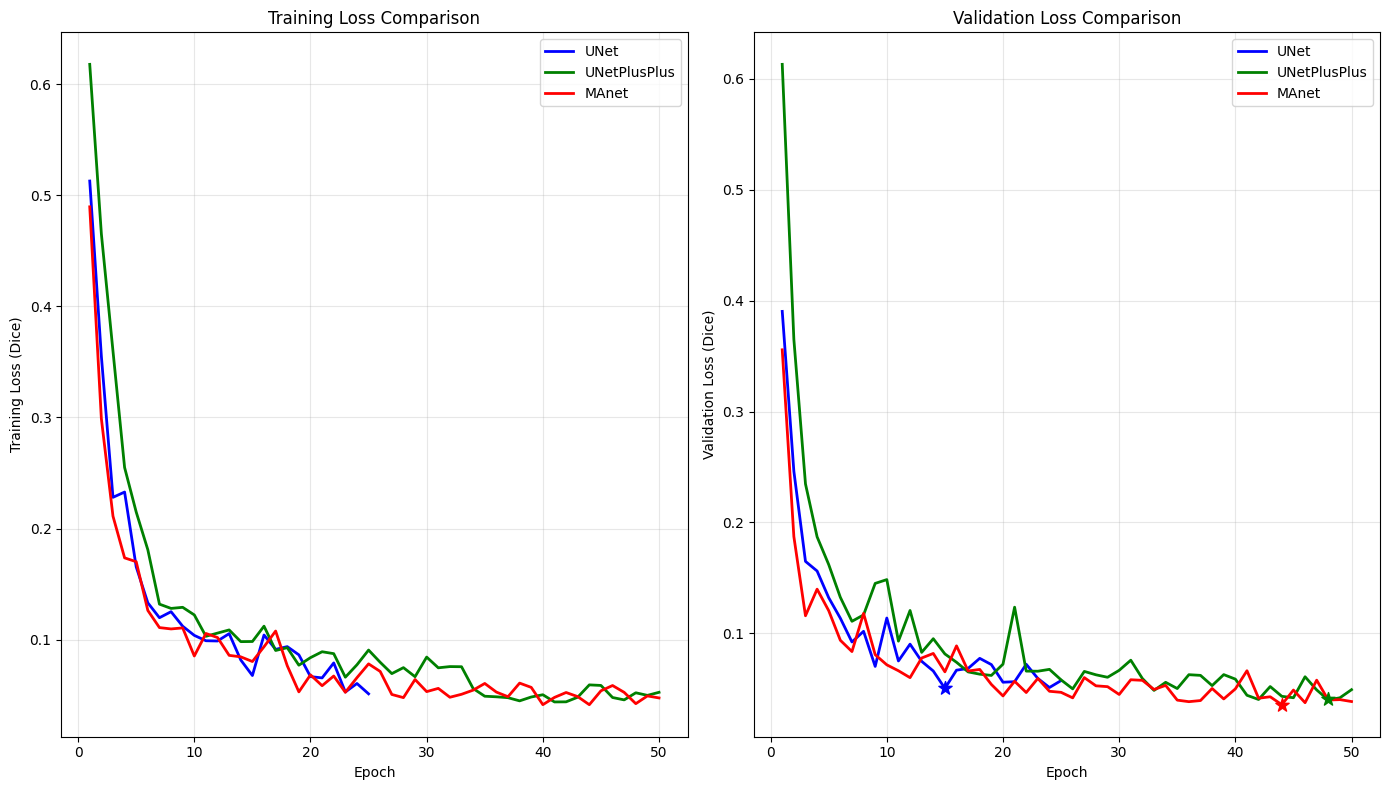

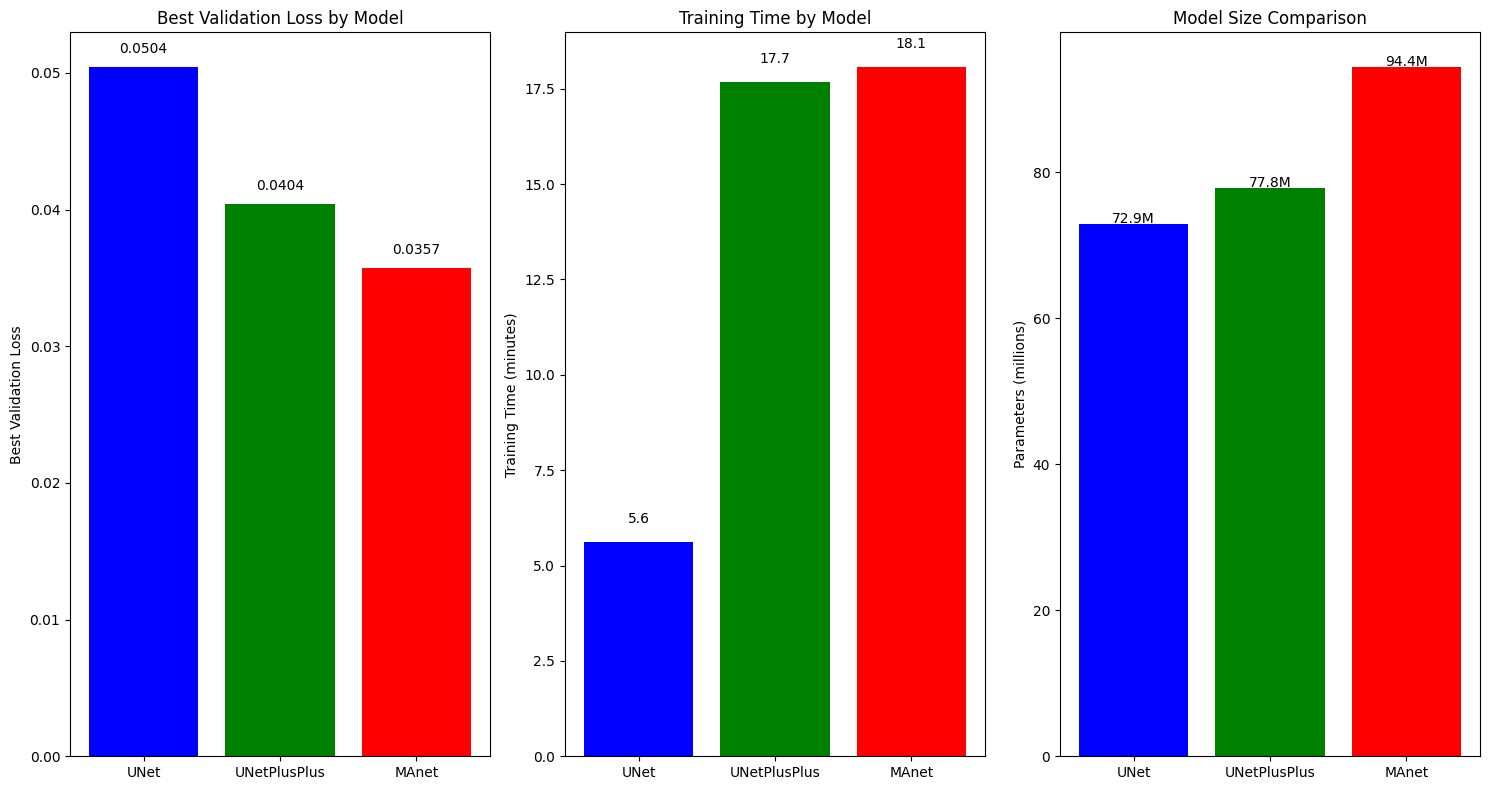


✓ Comparison plots saved to: training_comparison_3d.png, model_comparison_3d.png


In [49]:
# Plot training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

colors = {'UNet': 'blue', 'UNetPlusPlus': 'green', 'MAnet': 'red'}

# Training Loss
ax1 = axes[0]
for model_name, results in training_results.items():
    epochs = range(1, len(results['train_losses']) + 1)
    ax1.plot(epochs, results['train_losses'], label=model_name, color=colors.get(model_name, 'gray'), linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss (Dice)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Validation Loss
ax2 = axes[1]
for model_name, results in training_results.items():
    epochs = range(1, len(results['val_losses']) + 1)
    ax2.plot(epochs, results['val_losses'], label=model_name, color=colors.get(model_name, 'gray'), linewidth=2)
    # Mark best validation loss
    best_epoch = results['val_losses'].index(min(results['val_losses'])) + 1
    ax2.scatter([best_epoch], [results['best_val_loss']], color=colors.get(model_name, 'gray'), s=100, zorder=5, marker='*')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss (Dice)')
ax2.set_title('Validation Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison_3d.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

model_names = list(training_results.keys())
best_losses = [training_results[m]['best_val_loss'] for m in model_names]
training_times = [training_results[m]['total_training_time'] / 60 for m in model_names]
params = [training_results[m]['total_params'] / 1e6 for m in model_names]

# Best Validation Loss
axes[0].bar(model_names, best_losses, color=[colors[m] for m in model_names])
axes[0].set_ylabel('Best Validation Loss')
axes[0].set_title('Best Validation Loss by Model')
for i, v in enumerate(best_losses):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

# Training Time
axes[1].bar(model_names, training_times, color=[colors[m] for m in model_names])
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Time by Model')
for i, v in enumerate(training_times):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

# Model Parameters
axes[2].bar(model_names, params, color=[colors[m] for m in model_names])
axes[2].set_ylabel('Parameters (millions)')
axes[2].set_title('Model Size Comparison')
for i, v in enumerate(params):
    axes[2].text(i, v + 0.1, f'{v:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Comparison plots saved to: training_comparison_3d.png, model_comparison_3d.png")

In [50]:
# Load the best performing model for inference
best_model_name = min(training_results, key=lambda x: training_results[x]['best_val_loss'])
best_model_path = training_results[best_model_name]['model_path']

print(f"Loading best model: {best_model_name} from {best_model_path}")
models = get_models()
model = models[best_model_name]
model.load_state_dict(torch.load(best_model_path, weights_only=True))
model.to(device)
print(f"✓ Model loaded successfully")

Loading best model: MAnet from ./manet_3d__best.pth
✓ Model loaded successfully


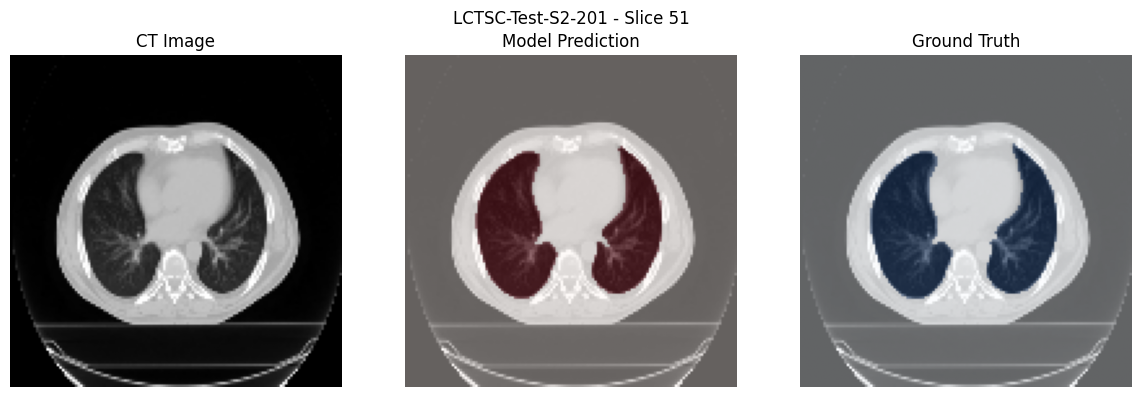


Metrics for this case:
  Dice: 0.9718
  IoU: 0.9451
  Sensitivity: 0.9578
  Precision: 0.9862


In [51]:
from monai.inferers import sliding_window_inference

# Make inference on a validation case
val_case_path = OUTPUT_DIR / 'Test' / 'LCTSC-Test-S2-201.npz'
data = np.load(val_case_path)
image = data['image']
mask_rlung = data['Lung_R']
mask_llung = data['Lung_L']
ground_truth_mask = np.maximum(mask_rlung, mask_llung).astype(np.float32)

# Prepare input tensor: (1, 1, H, W, D)
input_image_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).float().to(device)

model.eval()
with torch.no_grad():
    # Use sliding window inference for arbitrary volume sizes
    output = sliding_window_inference(
        inputs=input_image_tensor,
        roi_size=(64, 64, 32),  # Same patch size used during training
        sw_batch_size=4,
        predictor=model,
        overlap=0.5,
        mode='gaussian'
    )
    output_sigmoid = torch.sigmoid(output)
    output_mask_3d = (output_sigmoid > 0.5).float().cpu().squeeze().numpy()

# Visualize a specific slice
slice_idx = image.shape[2] // 2

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.title('CT Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.imshow(output_mask_3d[:, :, slice_idx], cmap='Reds', alpha=0.4)
plt.title('Model Prediction')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.imshow(ground_truth_mask[:, :, slice_idx], cmap='Blues', alpha=0.4)
plt.title('Ground Truth')
plt.axis('off')

plt.suptitle(f'LCTSC-Test-S2-201 - Slice {slice_idx}')
plt.tight_layout()
plt.show()

# Print metrics for this case
metrics = compute_metrics(output_mask_3d, ground_truth_mask)
print(f"\nMetrics for this case:")
print(f"  Dice: {metrics['dice']:.4f}")
print(f"  IoU: {metrics['iou']:.4f}")
print(f"  Sensitivity: {metrics['sensitivity']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")

In [52]:
# Evaluation metrics for segmentation models
from scipy.spatial.distance import directed_hausdorff
from scipy import ndimage as ndi

def compute_metrics(pred: np.ndarray, target: np.ndarray, smooth: float = 1e-6):
    """
    Compute segmentation metrics between prediction and ground truth.
    Both inputs should be binary masks (0 or 1).
    """
    pred = pred.astype(bool).flatten()
    target = target.astype(bool).flatten()
    
    # Basic counts
    tp = np.sum(pred & target)
    fp = np.sum(pred & ~target)
    fn = np.sum(~pred & target)
    tn = np.sum(~pred & ~target)
    
    # Dice Score
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    
    # IoU (Jaccard)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    
    # Sensitivity (Recall) - how much of the ground truth is captured
    sensitivity = (tp + smooth) / (tp + fn + smooth)
    
    # Specificity
    specificity = (tn + smooth) / (tn + fp + smooth)
    
    # Precision
    precision = (tp + smooth) / (tp + fp + smooth)
    
    # F1 Score (same as Dice for binary)
    f1 = (2 * precision * sensitivity) / (precision + sensitivity + smooth)
    
    return {
        'dice': dice,
        'iou': iou,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1
    }

def compute_hausdorff_distance(pred: np.ndarray, target: np.ndarray):
    """
    Compute Hausdorff distance between prediction and ground truth boundaries.
    Returns HD and HD95.
    """
    # Convert to boolean for boundary detection
    pred_bool = pred.astype(bool)
    target_bool = target.astype(bool)
    
    # Get boundary points
    pred_boundary = pred_bool ^ ndi.binary_erosion(pred_bool)
    target_boundary = target_bool ^ ndi.binary_erosion(target_bool)
    
    pred_points = np.argwhere(pred_boundary)
    target_points = np.argwhere(target_boundary)
    
    if len(pred_points) == 0 or len(target_points) == 0:
        return {'hausdorff': np.nan, 'hausdorff_95': np.nan}
    
    # Compute directed Hausdorff distances
    hd_pred_to_target = directed_hausdorff(pred_points, target_points)[0]
    hd_target_to_pred = directed_hausdorff(target_points, pred_points)[0]
    
    # Hausdorff distance (max of both directions)
    hd = max(hd_pred_to_target, hd_target_to_pred)
    
    # 95th percentile Hausdorff (more robust)
    from scipy.spatial.distance import cdist
    distances = cdist(pred_points, target_points)
    min_dist_pred = distances.min(axis=1)
    min_dist_target = distances.min(axis=0)
    all_distances = np.concatenate([min_dist_pred, min_dist_target])
    hd_95 = np.percentile(all_distances, 95)
    
    return {'hausdorff': hd, 'hausdorff_95': hd_95}

In [53]:
from monai.inferers import sliding_window_inference

def evaluate_model_on_full_volumes(model, data_dir, device, patch_size=(64, 64, 32), overlap=0.5):
    """
    Evaluate model on full 3D volumes using sliding window inference.
    """
    model.eval()
    all_metrics = []
    
    for file_name in sorted(os.listdir(data_dir)):
        if not file_name.endswith('.npz'):
            continue
            
        file_path = os.path.join(data_dir, file_name)
        npz_file = np.load(file_path)
        image = npz_file['image'].astype(np.float32)
        mask_r = npz_file['Lung_R']
        mask_l = npz_file['Lung_L']
        target = np.maximum(mask_r, mask_l).astype(np.float32)
        npz_file.close()
        
        # Prepare input tensor: (1, 1, H, W, D)
        image_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).float().to(device)
        
        with torch.no_grad():
            # Sliding window inference over the full volume
            pred = sliding_window_inference(
                inputs=image_tensor,
                roi_size=patch_size,
                sw_batch_size=4,
                predictor=model,
                overlap=overlap,
                mode='gaussian'
            )
        
        # Apply sigmoid and threshold
        pred_binary = (torch.sigmoid(pred) > 0.5).cpu().numpy()[0, 0]
        
        # Compute metrics on full volume
        metrics = compute_metrics(pred_binary, target)
        if pred_binary.sum() > 0 and target.sum() > 0:
            hd_metrics = compute_hausdorff_distance(pred_binary, target)
            metrics.update(hd_metrics)
        else:
            metrics['hausdorff'] = np.nan
            metrics['hausdorff_95'] = np.nan
        
        metrics['case'] = file_name
        all_metrics.append(metrics)
        print(f"  {file_name}: Dice={metrics['dice']:.4f}")
    
    metrics_df = pd.DataFrame(all_metrics)
    
    summary = {
        'dice_mean': metrics_df['dice'].mean(),
        'dice_std': metrics_df['dice'].std(),
        'iou_mean': metrics_df['iou'].mean(),
        'iou_std': metrics_df['iou'].std(),
        'sensitivity_mean': metrics_df['sensitivity'].mean(),
        'precision_mean': metrics_df['precision'].mean(),
        'hausdorff_95_mean': metrics_df['hausdorff_95'].dropna().mean(),
        'hausdorff_95_std': metrics_df['hausdorff_95'].dropna().std(),
    }
    
    return summary, metrics_df

# Evaluate all models on full volumes
evaluation_results = {}

for model_name in training_results.keys():
    print(f"\nEvaluating {model_name} on full volumes...")
    
    model_path = training_results[model_name]['model_path']
    models = get_models()
    model = models[model_name]
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    
    summary, detailed_metrics = evaluate_model_on_full_volumes(
        model, 
        VAL_IMAGE_DIR, 
        device,
        patch_size=(64, 64, 32),
        overlap=0.5
    )
    evaluation_results[model_name] = {
        'summary': summary,
        'detailed': detailed_metrics
    }
    
    print(f"  Dice: {summary['dice_mean']:.4f} ± {summary['dice_std']:.4f}")
    print(f"  IoU: {summary['iou_mean']:.4f} ± {summary['iou_std']:.4f}")


Evaluating UNet on full volumes...
  LCTSC-Test-S1-101.npz: Dice=0.9777
  LCTSC-Test-S1-102.npz: Dice=0.9737
  LCTSC-Test-S1-103.npz: Dice=0.9662
  LCTSC-Test-S1-104.npz: Dice=0.9733
  LCTSC-Test-S1-201.npz: Dice=0.9692
  LCTSC-Test-S1-202.npz: Dice=0.9677
  LCTSC-Test-S1-203.npz: Dice=0.9782
  LCTSC-Test-S1-204.npz: Dice=0.9810
  LCTSC-Test-S2-101.npz: Dice=0.9431
  LCTSC-Test-S2-102.npz: Dice=0.9641
  LCTSC-Test-S2-103.npz: Dice=0.9628
  LCTSC-Test-S2-104.npz: Dice=0.9517
  LCTSC-Test-S2-201.npz: Dice=0.9637
  LCTSC-Test-S2-202.npz: Dice=0.9628
  LCTSC-Test-S2-203.npz: Dice=0.9411
  LCTSC-Test-S2-204.npz: Dice=0.9586
  LCTSC-Test-S3-101.npz: Dice=0.9626
  LCTSC-Test-S3-102.npz: Dice=0.9616
  LCTSC-Test-S3-103.npz: Dice=0.9585
  LCTSC-Test-S3-104.npz: Dice=0.9742
  LCTSC-Test-S3-201.npz: Dice=0.9684
  LCTSC-Test-S3-202.npz: Dice=0.9814
  LCTSC-Test-S3-203.npz: Dice=0.9229
  LCTSC-Test-S3-204.npz: Dice=0.9635
  Dice: 0.9637 ± 0.0135
  IoU: 0.9302 ± 0.0248

Evaluating UNetPlusPlus on f

In [54]:
comparison_df = pd.DataFrame({
    model_name: {
        'Dice': f"{res['summary']['dice_mean']:.4f} ± {res['summary']['dice_std']:.4f}",
        'IoU': f"{res['summary']['iou_mean']:.4f} ± {res['summary']['iou_std']:.4f}",
        'Sensitivity': f"{res['summary']['sensitivity_mean']:.4f}",
        'Precision': f"{res['summary']['precision_mean']:.4f}",
        'HD95 (px)': f"{res['summary']['hausdorff_95_mean']:.2f} ± {res['summary']['hausdorff_95_std']:.2f}"
    }
    for model_name, res in evaluation_results.items()
}).T

print("\n" + "="*80)
print("MODEL COMPARISON - VALIDATION METRICS (Full Volume Evaluation)")
print("="*80)
print(comparison_df.to_string())

# Save detailed results
for model_name, res in evaluation_results.items():
    res['detailed'].to_csv(f'{model_name.lower()}_detailed_metrics.csv', index=False)
    print(f"\n✓ Saved detailed metrics: {model_name.lower()}_detailed_metrics.csv")


MODEL COMPARISON - VALIDATION METRICS (Full Volume Evaluation)
                         Dice              IoU Sensitivity Precision    HD95 (px)
UNet          0.9637 ± 0.0135  0.9302 ± 0.0248      0.9615    0.9664  1.32 ± 0.47
UNetPlusPlus  0.9674 ± 0.0156  0.9373 ± 0.0288      0.9598    0.9756  2.10 ± 4.59
MAnet         0.9716 ± 0.0119  0.9450 ± 0.0224      0.9696    0.9740  1.15 ± 0.31

✓ Saved detailed metrics: unet_detailed_metrics.csv

✓ Saved detailed metrics: unetplusplus_detailed_metrics.csv

✓ Saved detailed metrics: manet_detailed_metrics.csv


In [55]:
# Make inference on a hidden test case
image_raw = np.load('hidden_test_set/LUNG1-010/ct.npy')

# Apply simple preprocessing: windowing, resizing, and normalization (no cropping)
w_min, w_max = -1000, 400
windowed_image = hu_windowing(image_raw, w_min, w_max)
resized_image = resize_volume(windowed_image, 128)
# Fixed normalization using windowing parameters
hidden_test_image = (resized_image - w_min) / (w_max - w_min)

print(f"Original image shape: {image_raw.shape}")
print(f"Preprocessed image shape: {hidden_test_image.shape}")
print(f"Image range: [{hidden_test_image.min():.3f}, {hidden_test_image.max():.3f}]")

Original image shape: (512, 512, 91)
Preprocessed image shape: (128, 128, 91)
Image range: [-0.000, 1.000]


In [56]:
# ============================================================================
# Select and load model for inference on hidden test set
# ============================================================================
import segmentation_models_pytorch_3d as smp

available_models = {
    'UNet':        ('unet_3d__best.pth',        smp.Unet),
    'UNetPlusPlus':('unetplusplus_3d__best.pth', smp.UnetPlusPlus),
    'MAnet':       ('manet_3d__best.pth',        smp.MAnet),
}

# -------- CHANGE THIS TO SELECT YOUR MODEL --------
SELECTED_MODEL = 'MAnet'  # Options: 'UNet', 'UNetPlusPlus', 'MAnet'
# ---------------------------------------------------

weight_file, model_cls = available_models[SELECTED_MODEL]
model = model_cls(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
)
model.load_state_dict(torch.load(weight_file, map_location=device, weights_only=True))
model.to(device)
model.eval()
print(f"Loaded {SELECTED_MODEL} from {weight_file} on {device}")

Loaded MAnet from manet_3d__best.pth on cuda


In [57]:
# Generate prediction for all test cases with body mask and save the image and the mask in two separate .npy files
test_cases = sorted(os.listdir('hidden_test_set'))

model.eval()

for case in test_cases:
    case_path = os.path.join('hidden_test_set', case)
    image_raw = np.load(os.path.join(case_path, 'ct.npy'))
    
    # Preprocess the image
    windowed_image = hu_windowing(image_raw, w_min, w_max)
    resized_image = resize_volume(windowed_image, 128)
    hidden_test_image = (resized_image - w_min) / (w_max - w_min)
    
    # Prepare input tensor
    input_tensor = torch.from_numpy(hidden_test_image).unsqueeze(0).unsqueeze(0).float().to(device)
    
    # Predict mask
    with torch.no_grad():
        pred = sliding_window_inference(
            inputs=input_tensor,
            roi_size=(64, 64, 32),
            sw_batch_size=4,
            predictor=model,
            overlap=0.5,
            mode='gaussian'
        )
    
    pred_binary = (torch.sigmoid(pred) > 0.5).cpu().numpy()[0, 0]
    
    # Apply body mask to remove false positives outside the patient body
    body_mask = get_body_mask_3d(hidden_test_image)
    pred_binary = (pred_binary * body_mask).astype(np.uint8)
    
    # Save the preprocessed image and predicted mask
    np.save(os.path.join('test_cases_inference', f'{case}_preprocessed_image.npy'), hidden_test_image)
    np.save(os.path.join('test_cases_inference', f'{case}_predicted_mask.npy'), pred_binary)
    
    print(f"Processed {case}: saved preprocessed image and predicted mask.")

/home/andre/HealthcareImaging/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning:

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)

/home/andre/HealthcareImaging/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning:

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)



Processed LUNG1-001: saved preprocessed image and predicted mask.
Processed LUNG1-002: saved preprocessed image and predicted mask.
Processed LUNG1-003: saved preprocessed image and predicted mask.
Processed LUNG1-004: saved preprocessed image and predicted mask.
Processed LUNG1-005: saved preprocessed image and predicted mask.
Processed LUNG1-006: saved preprocessed image and predicted mask.
Processed LUNG1-007: saved preprocessed image and predicted mask.
Processed LUNG1-008: saved preprocessed image and predicted mask.
Processed LUNG1-009: saved preprocessed image and predicted mask.
Processed LUNG1-010: saved preprocessed image and predicted mask.


In [ ]:
# ============================================================================
# 3D Visualization of saved test case predictions
# ============================================================================
import plotly.graph_objects as go
from skimage import measure
from ipywidgets import interact, Dropdown

saved_cases = sorted(os.listdir('hidden_test_set'))

def visualize_case_3d(case_name):
    case_path = os.path.join('hidden_test_set', case_name)
    img_file = os.path.join('test_cases_inference', f'{case_name}_preprocessed_image.npy')
    mask_file = os.path.join('test_cases_inference', f'{case_name}_predicted_mask.npy')
    
    if not os.path.exists(img_file) or not os.path.exists(mask_file):
        print(f"Files not found for {case_name}. Run the inference cell first.")
        return
    
    image = np.load(img_file)
    mask = np.load(mask_file)
    
    # Build body mask from the preprocessed image
    body = image
    
    fig = go.Figure()
    
    # Body surface (gray, transparent)
    if body.max() > 0:
        try:
            verts_b, faces_b, _, _ = measure.marching_cubes(body, level=0.5)
            fig.add_trace(go.Mesh3d(
                x=verts_b[:, 0], y=verts_b[:, 1], z=verts_b[:, 2],
                i=faces_b[:, 0], j=faces_b[:, 1], k=faces_b[:, 2],
                opacity=0.15, color='gray', name='Body Surface'
            ))
        except ValueError:
            print(f"Could not generate body surface for {case_name}")
    
    # Predicted lung mask (red)
    if mask.max() > 0:
        try:
            verts_m, faces_m, _, _ = measure.marching_cubes(mask.astype(np.float32), level=0.5)
            fig.add_trace(go.Mesh3d(
                x=verts_m[:, 0], y=verts_m[:, 1], z=verts_m[:, 2],
                i=faces_m[:, 0], j=faces_m[:, 1], k=faces_m[:, 2],
                opacity=0.6, color='red', name='Predicted Lung Mask'
            ))
        except ValueError:
            print(f"Could not generate mask surface for {case_name}")
    else:
        print(f"Warning: predicted mask for {case_name} is empty!")
    
    fig.update_layout(
        title=f'3D Lung Segmentation — {case_name}',
        scene=dict(aspectmode='data'),
        width=900, height=800,
        legend=dict(x=0.02, y=0.98)
    )
    fig.show()
    
    print(f"Image shape: {image.shape}, Mask voxels: {mask.sum()}")

interact(visualize_case_3d, case_name=Dropdown(
    options=saved_cases,
    value=saved_cases[0],
    description='Test Case:'
))

interactive(children=(Dropdown(description='Test Case:', options=('LUNG1-001', 'LUNG1-002', 'LUNG1-003', 'LUNG…

<function __main__.visualize_case_3d(case_name)>

In [59]:
from monai.inferers import sliding_window_inference

def get_body_mask_3d(image_3d: np.ndarray, threshold: float = 0.6):
    """
    Create a 3D body mask to exclude air outside the patient.
    """
    from scipy import ndimage as ndi
    
    body_mask_3d = np.zeros_like(image_3d)
    for i in range(image_3d.shape[2]):
        binary = (image_3d[:, :, i] > threshold).astype(np.uint8)
        filled = ndi.binary_fill_holes(binary)
        labeled, num_features = ndi.label(filled)
        
        if num_features > 0:
            component_sizes = ndi.sum(filled, labeled, range(1, num_features + 1))
            largest_component = np.argmax(component_sizes) + 1
            body_mask_3d[:, :, i] = (labeled == largest_component).astype(np.float32)
        else:
            body_mask_3d[:, :, i] = filled.astype(np.float32)
    
    return body_mask_3d

# Perform 3D inference on full volume using sliding window
print("Running 3D inference on hidden test volume...")
input_tensor = torch.from_numpy(hidden_test_image).unsqueeze(0).unsqueeze(0).float().to(device)

model.eval()
with torch.no_grad():
    output = sliding_window_inference(
        inputs=input_tensor,
        roi_size=(64, 64, 32),
        sw_batch_size=4,
        predictor=model,
        overlap=0.5,
        mode='gaussian'
    )
    output_sigmoid = torch.sigmoid(output)
    predicted_mask_3d = (output_sigmoid > 0.5).float().cpu().squeeze().numpy()

# Apply body mask
body_mask_3d = get_body_mask_3d(hidden_test_image)
filtered_mask_3d = predicted_mask_3d * body_mask_3d

print(f"Predicted mask shape: {predicted_mask_3d.shape}")
print(f"Lung voxels predicted: {predicted_mask_3d.sum():.0f}")
print(f"Lung voxels after body mask: {filtered_mask_3d.sum():.0f}")

# Interactive viewer using precomputed 3D mask
def interactive_slice_viewer_hidden_test(image_3d, mask_3d, body_mask_3d):
    """Interactive viewer for browsing through CT scan slices with precomputed 3D mask."""
    
    def show_slice(slice_num):
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.imshow(image_3d[:, :, slice_num], cmap='gray')
        plt.title('CT Image')
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(image_3d[:, :, slice_num], cmap='gray')
        plt.imshow(mask_3d[:, :, slice_num], cmap='Reds', alpha=0.4)
        plt.title('Model Prediction')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(image_3d[:, :, slice_num], cmap='gray')
        plt.imshow(body_mask_3d[:, :, slice_num], cmap='Blues', alpha=0.3)
        plt.title('Body Mask')
        plt.axis('off')
        
        plt.suptitle(f'Slice {slice_num}/{image_3d.shape[2]-1}')
        plt.tight_layout()
        plt.show()

    interact(show_slice, slice_num=IntSlider(min=0, max=image_3d.shape[2]-1, step=1, value=image_3d.shape[2]//2, description='Slice'))

# Interactive viewing
interactive_slice_viewer_hidden_test(hidden_test_image, filtered_mask_3d, body_mask_3d)

Running 3D inference on hidden test volume...
Predicted mask shape: (128, 128, 91)
Lung voxels predicted: 79058
Lung voxels after body mask: 78612


interactive(children=(IntSlider(value=45, description='Slice', max=90), Output()), _dom_classes=('widget-inter…

In [60]:
import plotly.graph_objects as go
from skimage import measure

# Use the precomputed 3D masks from the previous cell
# filtered_mask_3d and body_mask_3d are already computed

# Create 3D surfaces
fig = go.Figure()

# Body surface (gray)
if body_mask_3d.max() > 0:
    try:
        verts_body, faces_body, _, _ = measure.marching_cubes(body_mask_3d, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_body[:, 0], y=verts_body[:, 1], z=verts_body[:, 2],
            i=faces_body[:, 0], j=faces_body[:, 1], k=faces_body[:, 2],
            opacity=0.2,
            color='gray',
            name='Body Surface'
        ))
    except ValueError:
        print("Could not generate body surface")

# Predicted lung surface (red)
if filtered_mask_3d.max() > 0:
    try:
        verts_pred, faces_pred, _, _ = measure.marching_cubes(filtered_mask_3d, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_pred[:, 0], y=verts_pred[:, 1], z=verts_pred[:, 2],
            i=faces_pred[:, 0], j=faces_pred[:, 1], k=faces_pred[:, 2],
            opacity=0.6,
            color='red',
            name='Model Prediction'
        ))
    except ValueError:
        print("Could not generate prediction surface")

fig.update_layout(
    title='3D Lung Segmentation - Model Prediction (Sliding Window Inference)',
    scene=dict(aspectmode='data'),
    width=900, height=800,
    legend=dict(x=0.02, y=0.98)
)
fig.show()

Model loaded from ./manet_3d__best.pth on cuda
Preprocessed volume: (128, 128, 91), range [-0.000, 1.000]

Lung voxels WITHOUT body mask: 79058
Lung voxels WITH body mask:    78612
Spurious voxels removed:       446 (0.6%)


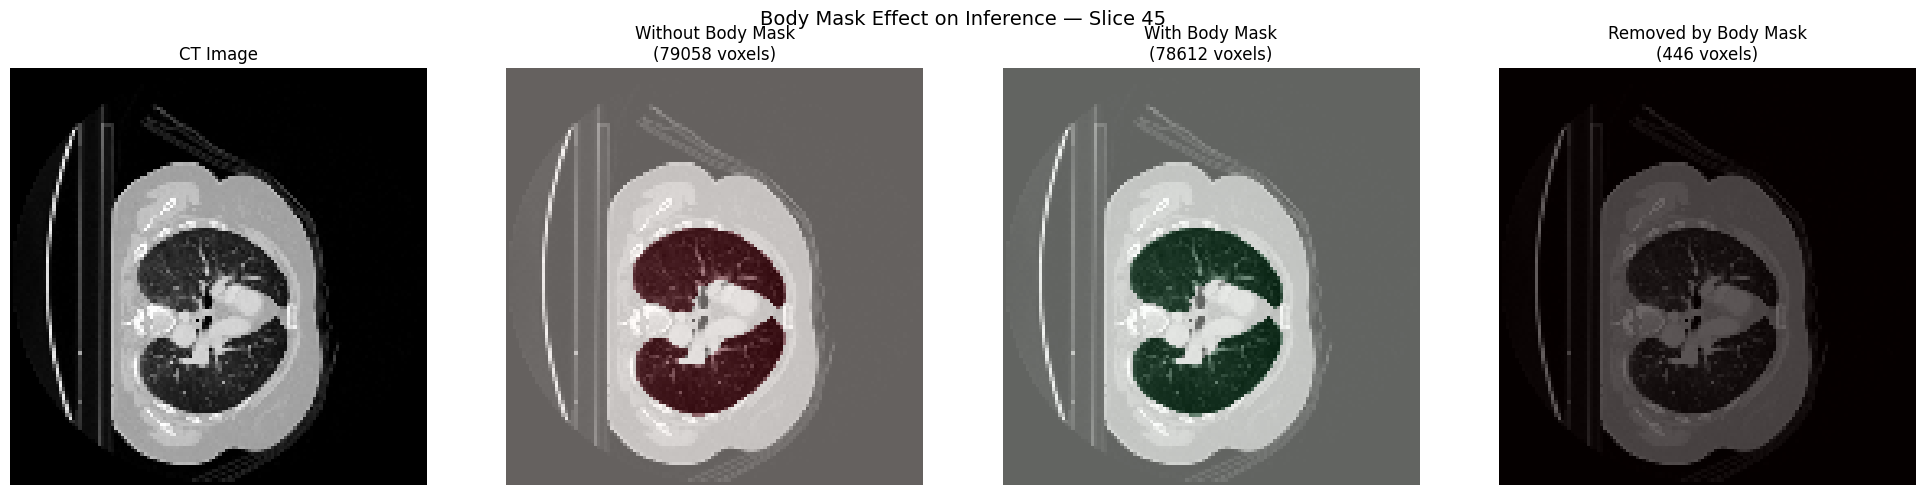

interactive(children=(IntSlider(value=45, description='Slice', max=90), Output()), _dom_classes=('widget-inter…

<function __main__.compare_body_mask(slice_num)>

In [61]:
# ============================================================================
# INDEPENDENT CELL: Body Mask vs No Body Mask Comparison
# ============================================================================
# This cell is fully self-contained — loads model, preprocesses data, infers,
# and compares results with and without body mask filtering.

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from scipy import ndimage as ndi
from ipywidgets import interact, IntSlider
import segmentation_models_pytorch_3d as smp
from monai.inferers import sliding_window_inference

# --- Configuration ---
MODEL_PATH = './manet_3d__best.pth'  # Change to your best model .pth
HIDDEN_TEST_PATH = 'hidden_test_set/LUNG1-010/ct.npy'
W_MIN, W_MAX = -1000, 400
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Load model ---
model = smp.MAnet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print(f"Model loaded from {MODEL_PATH} on {DEVICE}")

# --- Preprocessing helpers ---
def _resize_volume(image, dim):
    H, W, Z = image.shape
    return zoom(image, (dim / H, dim / W, 1.0), order=1)

def _hu_windowing(image, wmin, wmax):
    return np.clip(image, wmin, wmax)

def _get_body_mask_3d(image_3d, threshold=0.6):
    body_mask = np.zeros_like(image_3d)
    for i in range(image_3d.shape[2]):
        binary = (image_3d[:, :, i] > threshold).astype(np.uint8)
        filled = ndi.binary_fill_holes(binary)
        labeled, n = ndi.label(filled)
        if n > 0:
            sizes = ndi.sum(filled, labeled, range(1, n + 1))
            body_mask[:, :, i] = (labeled == (np.argmax(sizes) + 1)).astype(np.float32)
        else:
            body_mask[:, :, i] = filled.astype(np.float32)
    return body_mask

# --- Preprocess hidden test volume ---
image_raw = np.load(HIDDEN_TEST_PATH)
windowed = _hu_windowing(image_raw, W_MIN, W_MAX)
resized = _resize_volume(windowed, 128)
normalized = (resized - W_MIN) / (W_MAX - W_MIN)
print(f"Preprocessed volume: {normalized.shape}, range [{normalized.min():.3f}, {normalized.max():.3f}]")

# --- Inference ---
input_tensor = torch.from_numpy(normalized).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

with torch.no_grad():
    output = sliding_window_inference(
        inputs=input_tensor,
        roi_size=(64, 64, 32),
        sw_batch_size=4,
        predictor=model,
        overlap=0.5,
        mode='gaussian'
    )
    pred_sigmoid = torch.sigmoid(output).cpu().squeeze().numpy()
    pred_no_mask = (pred_sigmoid > 0.5).astype(np.float32)

# --- Body mask filtering ---
body_mask = _get_body_mask_3d(normalized)
pred_with_mask = pred_no_mask * body_mask

voxels_no_mask = int(pred_no_mask.sum())
voxels_with_mask = int(pred_with_mask.sum())
voxels_removed = voxels_no_mask - voxels_with_mask
print(f"\nLung voxels WITHOUT body mask: {voxels_no_mask}")
print(f"Lung voxels WITH body mask:    {voxels_with_mask}")
print(f"Spurious voxels removed:       {voxels_removed} ({100*voxels_removed/max(voxels_no_mask,1):.1f}%)")

# --- Difference map ---
diff_mask = pred_no_mask - pred_with_mask  # 1 where body mask removed predictions

# --- Side-by-side comparison plot (static, mid-slice) ---
slice_idx = normalized.shape[2] // 2
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(normalized[:, :, slice_idx], cmap='gray')
axes[0].set_title('CT Image')
axes[0].axis('off')

axes[1].imshow(normalized[:, :, slice_idx], cmap='gray')
axes[1].imshow(pred_no_mask[:, :, slice_idx], cmap='Reds', alpha=0.4)
axes[1].set_title(f'Without Body Mask\n({voxels_no_mask} voxels)')
axes[1].axis('off')

axes[2].imshow(normalized[:, :, slice_idx], cmap='gray')
axes[2].imshow(pred_with_mask[:, :, slice_idx], cmap='Greens', alpha=0.4)
axes[2].set_title(f'With Body Mask\n({voxels_with_mask} voxels)')
axes[2].axis('off')

axes[3].imshow(normalized[:, :, slice_idx], cmap='gray')
axes[3].imshow(diff_mask[:, :, slice_idx], cmap='hot', alpha=0.6)
axes[3].set_title(f'Removed by Body Mask\n({voxels_removed} voxels)')
axes[3].axis('off')

plt.suptitle(f'Body Mask Effect on Inference — Slice {slice_idx}', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interactive slice viewer ---
def compare_body_mask(slice_num):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(normalized[:, :, slice_num], cmap='gray')
    axes[0].set_title('CT Image')
    axes[0].axis('off')
    
    axes[1].imshow(normalized[:, :, slice_num], cmap='gray')
    axes[1].imshow(pred_no_mask[:, :, slice_num], cmap='Reds', alpha=0.4)
    axes[1].set_title('Without Body Mask')
    axes[1].axis('off')
    
    axes[2].imshow(normalized[:, :, slice_num], cmap='gray')
    axes[2].imshow(pred_with_mask[:, :, slice_num], cmap='Greens', alpha=0.4)
    axes[2].set_title('With Body Mask')
    axes[2].axis('off')
    
    axes[3].imshow(normalized[:, :, slice_num], cmap='gray')
    axes[3].imshow(diff_mask[:, :, slice_num], cmap='hot', alpha=0.6)
    axes[3].set_title('Removed by Body Mask')
    axes[3].axis('off')
    
    plt.suptitle(f'Slice {slice_num}/{normalized.shape[2]-1}')
    plt.tight_layout()
    plt.show()

interact(compare_body_mask, slice_num=IntSlider(
    min=0, max=normalized.shape[2]-1, step=1,
    value=normalized.shape[2]//2, description='Slice'
))

In [62]:
# 3D Visualization: Body Mask vs No Body Mask comparison
# Uses pred_no_mask, pred_with_mask, diff_mask, body_mask from the cell above

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from skimage import measure

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'mesh3d'}, {'type': 'mesh3d'}]],
    subplot_titles=('Without Body Mask (Raw Prediction)', 'With Body Mask (Filtered)')
)

# --- Left: Raw prediction (no body mask) ---
if pred_no_mask.max() > 0:
    try:
        verts, faces, _, _ = measure.marching_cubes(pred_no_mask, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            opacity=0.6, color='red', name='Raw Prediction'
        ), row=1, col=1)
    except ValueError:
        print("Could not generate raw prediction surface")

# Add body outline on left for reference
if body_mask.max() > 0:
    try:
        verts_b, faces_b, _, _ = measure.marching_cubes(body_mask, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_b[:, 0], y=verts_b[:, 1], z=verts_b[:, 2],
            i=faces_b[:, 0], j=faces_b[:, 1], k=faces_b[:, 2],
            opacity=0.1, color='gray', name='Body Surface'
        ), row=1, col=1)
    except ValueError:
        pass

# --- Right: Filtered prediction (with body mask) ---
if pred_with_mask.max() > 0:
    try:
        verts_f, faces_f, _, _ = measure.marching_cubes(pred_with_mask, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_f[:, 0], y=verts_f[:, 1], z=verts_f[:, 2],
            i=faces_f[:, 0], j=faces_f[:, 1], k=faces_f[:, 2],
            opacity=0.6, color='green', name='Filtered Prediction'
        ), row=1, col=2)
    except ValueError:
        print("Could not generate filtered prediction surface")

# Show removed voxels on right subplot
if diff_mask.max() > 0:
    try:
        verts_d, faces_d, _, _ = measure.marching_cubes(diff_mask, level=0.5)
        fig.add_trace(go.Mesh3d(
            x=verts_d[:, 0], y=verts_d[:, 1], z=verts_d[:, 2],
            i=faces_d[:, 0], j=faces_d[:, 1], k=faces_d[:, 2],
            opacity=0.6, color='orange', name='Removed by Body Mask'
        ), row=1, col=2)
    except ValueError:
        pass

# Add body outline on right
if body_mask.max() > 0:
    try:
        fig.add_trace(go.Mesh3d(
            x=verts_b[:, 0], y=verts_b[:, 1], z=verts_b[:, 2],
            i=faces_b[:, 0], j=faces_b[:, 1], k=faces_b[:, 2],
            opacity=0.1, color='gray', name='Body Surface', showlegend=False
        ), row=1, col=2)
    except:
        pass

fig.update_layout(
    title=f'3D Body Mask Effect — Removed {voxels_removed} spurious voxels ({100*voxels_removed/max(voxels_no_mask,1):.1f}%)',
    width=1400, height=700,
    legend=dict(x=0.4, y=1.05, orientation='h'),
)

# Sync camera across subplots
for col in [1, 2]:
    fig.update_scenes(aspectmode='data', row=1, col=col)

fig.show()

Raw volume shape: (512, 512, 91)
HU range: [-1024, 1000]
HU mean: -725.3, std: 434.7


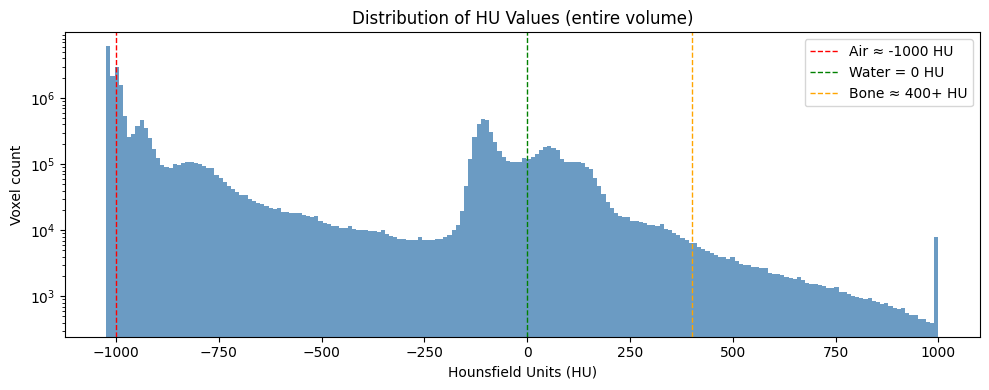

interactive(children=(IntSlider(value=45, continuous_update=False, description='Slice', max=90), Output()), _d…

In [63]:
# ============================================================================
# HU Value Heatmap & Distribution of Raw CT Image
# ============================================================================
# Uses `image_raw` from the cell above (raw HU values before windowing).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from ipywidgets import interact, IntSlider

# --- Global HU statistics ---
print(f"Raw volume shape: {image_raw.shape}")
print(f"HU range: [{image_raw.min():.0f}, {image_raw.max():.0f}]")
print(f"HU mean: {image_raw.mean():.1f}, std: {image_raw.std():.1f}")

# --- 1) Overall HU Histogram ---
fig_hist, ax_hist = plt.subplots(1, 1, figsize=(10, 4))
ax_hist.hist(image_raw.ravel(), bins=200, color='steelblue', edgecolor='none', alpha=0.8)
ax_hist.set_xlabel('Hounsfield Units (HU)')
ax_hist.set_ylabel('Voxel count')
ax_hist.set_title('Distribution of HU Values (entire volume)')
ax_hist.axvline(x=-1000, color='red', ls='--', lw=1, label='Air ≈ -1000 HU')
ax_hist.axvline(x=0, color='green', ls='--', lw=1, label='Water = 0 HU')
ax_hist.axvline(x=400, color='orange', ls='--', lw=1, label='Bone ≈ 400+ HU')
ax_hist.legend()
ax_hist.set_yscale('log')
plt.tight_layout()
plt.show()

# --- 2) Interactive slice-by-slice HU heatmap ---
# Use a diverging colormap centered at 0 HU (water)
vmin_hu, vmax_hu = image_raw.min(), image_raw.max()

@interact(slice_idx=IntSlider(min=0, max=image_raw.shape[2]-1,
                               value=image_raw.shape[2]//2,
                               description='Slice', continuous_update=False))
def show_hu_heatmap(slice_idx):
    slc = image_raw[:, :, slice_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                              gridspec_kw={'width_ratios': [1, 1]})

    # Left: HU heatmap with diverging colormap (centered at 0)
    norm = TwoSlopeNorm(vmin=vmin_hu, vcenter=0, vmax=vmax_hu)
    im = axes[0].imshow(slc, cmap='RdBu_r', norm=norm, origin='lower')
    axes[0].set_title(f'HU Heatmap — Slice {slice_idx}')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label('Hounsfield Units (HU)')

    # Right: histogram for this slice only
    axes[1].hist(slc.ravel(), bins=150, color='steelblue', edgecolor='none', alpha=0.8)
    axes[1].set_xlabel('HU')
    axes[1].set_ylabel('Pixel count')
    axes[1].set_title(f'HU Distribution — Slice {slice_idx}')
    axes[1].axvline(x=-1000, color='red', ls='--', lw=1, label='Air')
    axes[1].axvline(x=0, color='green', ls='--', lw=1, label='Water')
    axes[1].axvline(x=400, color='orange', ls='--', lw=1, label='Bone')
    axes[1].legend(fontsize=8)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()